# Financial Forecasting: RNOA and EPS


## Introduction

The aim of this report is to analyse the efficacy of models which forecast common financial ratios: Return on Net Operating Assests (*RNOA*) and Earnings per Share (*EPS*) for public companies. *RNOA* measures the return from a firm's operating activities due to its asset levels - making it a better ratio than Return on Equity which also includes the use of asset leveraging to inflate returns (Schmidt 2021) -, and *EPS* meausres business profitability per share, which is a good indicator of overall financial performance but does not equate to a high Return on Net Operating Assets, as asset levels are not reflected in *EPS* (Xero 2024).

In order to conduct these analyses, this report will draw from two datasets: the first gives 18 finanical indicators (which may all be used to calculate *RNOA*) across 21,735 firms from 2000 to 2020. The second gives the Earnings per Share of 12,910 firms across 2009 to 2020. The methodology of this analysis will be to prepare (*Data Preparation* section) a multiple linear regression for *RNOA*, analysing (*Complex Modelling* section) the 18 financial variables listed in the dataset for regression correlation and accuracy. Time series plots (*Descriptive Statistics* section) will help readers visualise how these independant regression variables interact with each other and correlation analyis will be employed. Finally random walk and and moving average models will be used to forecast *EPS* accuracy (*Simple Modelling* section), and the efficacy of each model in comparison to the other will be discussed. 

## Data Preparation

Mutliple linear regression will be used to model *RNOA* in future t+1 time periods. Drawing on Soliman (2008) the regression model will take the form *$RNOA_1 = RNOA_0 + PM_0 + ATO_0 + TACC_0 + INV_0 + AR_0 + ETR_0 + SGX_0$*, where the future-period Return on Net Operating Assets is determined by a linear combination of present-period Return on Net Operating Assets, Profit Margin, Asset Turnover, Total Accruals Change, Variable Interest Rates, Accounts Recievable, Effective Tax Rate and Return on Selling Expenses.

In [332]:
# import the data
import numpy as np
import pandas as pd
import warnings

acc_df = pd.read_csv('data/accounting_data.csv') 
acc_df.head()

,gvkey,datadate,fyear,at,ceq,che,csho,dlc,dltt,invt,...,mib,ni,oancf,oiadp,pi,pstk,rect,sale,txt,xsga
0,1004,20010531,2000,701.854,340.212,13.809,26.937,13.652,179.987,320.590,...,0.0,18.531,46.093,45.790,20.220,0.0,115.187,874.255,1.689,96.077
1,1004,20020531,2001,710.199,310.235,34.522,31.870,42.525,217.699,286.588,...,0.0,-58.939,-33.315,4.711,-98.229,0.0,77.528,638.721,-39.290,85.037
2,1004,20030531,2002,686.621,294.988,29.154,31.851,92.256,164.658,259.954,...,0.0,-12.410,34.733,3.573,-19.490,0.0,66.322,606.337,-7.080,78.845
3,1004,20040531,2003,709.292,301.684,41.010,32.245,3.392,248.666,247.245,...,0.0,3.504,14.572,20.811,1.707,0.0,104.661,651.958,-1.797,81.165
4,1004,20050531,2004,732.230,314.744,50.338,32.586,3.745,227.159,255.477,...,NaN,15.453,50.938,33.824,21.639,0.0,127.121,747.848,3.067,87.902


In [333]:
# list the variables
acc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285491 entries, 0 to 285490
Data columns (total 21 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gvkey     285491 non-null  int64  
 1   datadate  285491 non-null  int64  
 2   fyear     285491 non-null  int64  
 3   at        285491 non-null  float64
 4   ceq       190484 non-null  float64
 5   che       190847 non-null  float64
 6   csho      186412 non-null  float64
 7   dlc       192323 non-null  float64
 8   dltt      278463 non-null  float64
 9   invt      188769 non-null  float64
 10  ivst      187323 non-null  float64
 11  mib       187758 non-null  float64
 12  ni        285491 non-null  float64
 13  oancf     186262 non-null  float64
 14  oiadp     190832 non-null  float64
 15  pi        283993 non-null  float64
 16  pstk      190339 non-null  float64
 17  rect      188569 non-null  float64
 18  sale      285119 non-null  float64
 19  txt       284037 non-null  float64
 20  xsga

In addition to the 18 financial variables listed, this regression will also need the company identifiers (*gvkey*) and fiscal year (*fyear*). Moreover the 8 independant financial ratios for the linear regression need to be calulated using the 18 variables given, as well as Net Operating Assets (*NOA*) which is proportional to the sum of total long-term debt (*DLTT*) and current liabilities (*DLC*), total common (*CEQ*) and preferred equity (*PSTK*), and minorty interests (*MIB*), minus cash (*CHE*) and short-term investments (*IVST*). 

In [334]:
# select variables and drop observations with missing values
a_df1 = acc_df.loc[(acc_df.sale>0) & (acc_df['at']>0) & (acc_df.ceq>0)][['gvkey', 'datadate', 'fyear', 'at', 'dltt', 'dlc', 'ceq', 'pstk', 'mib', 'che', 'ivst', 'oiadp', 'sale', 'ni', 'oancf', 'invt', 'rect', 'txt', 'xsga', 'pi']].dropna()

# change date format
a_df1['Date'] = pd.to_datetime(a_df1.datadate.apply(str))

# calculate NOA
a_df1['NOA'] = a_df1.dltt + a_df1.dlc + a_df1.ceq + a_df1.pstk + a_df1.mib - a_df1.che + a_df1.ivst

In [339]:
# calculate the ratios RNOA, PM, ATO, TACC, INV, AR, ETR and SGX
a_df1['RNOA'] = a_df1.oiadp/a_df1.NOA
a_df1['PM'] = a_df1.oiadp/a_df1.sale
a_df1['ATO'] = a_df1.sale/a_df1.NOA
a_df1['TACC'] = a_df1.ni - a_df1.oancf
a_df1['INV'] = a_df1.invt/a_df1.NOA
a_df1['AR'] = a_df1.rect/a_df1.NOA
a_df1['ETR'] = a_df1.txt/a_df1.pi
a_df1['SGX'] = a_df1.xsga/a_df1.NOA

# add the column RNOA and NI in period time + 1
a_df1 = a_df1.sort_values(by = ['gvkey', 'fyear']) 
a_df1['NI1'] = a_df1.groupby(['gvkey'])['ni'].shift(-1)
a_df1['RNOA1'] = a_df1.groupby(['gvkey'])['RNOA'].shift(-1)
a_df1['ROA'] = a_df1['NI1']/a_df1['at']

In [340]:
# create a new dataframe with relevant regression variables
a_df2 = a_df1[['gvkey', 'fyear', 'Date', 'RNOA1', 'RNOA', 'PM', 'ATO', 'TACC', 'INV', 'AR', 'ETR', 'SGX', 'ROA']]

# rename variables comapny ID and fiscal year
a_df2 = a_df2.rename(columns = {'gvkey': 'Company ID', 'fyear' : 'Fiscal Year'})
warnings.filterwarnings("ignore")
a_df2.describe()

,Company ID,Fiscal Year,Date,RNOA1,RNOA,PM,ATO,TACC,INV,AR,ETR,SGX,ROA
count,110712.000000,110712.000000,110712,9.612800e+04,1.107120e+05,110712.000000,1.107120e+05,110712.000000,1.107060e+05,1.107070e+05,1.107110e+05,1.107120e+05,96128.000000
mean,77387.145079,2009.667443,2010-08-20 09:01:13.357901568,NaN,NaN,-2.180584,inf,-241.820827,inf,inf,NaN,inf,-0.038006
min,1004.000000,2000.000000,2000-06-30 00:00:00,-inf,-inf,-10596.666667,-1.467093e+16,-219891.000000,-7.522813e+15,-2.882304e+14,-inf,-2.300078e+17,-307.333333
25%,16898.000000,2005.000000,2005-06-30 00:00:00,-9.142968e-03,-2.038956e-02,-0.021594,4.377767e-01,-77.488500,5.477295e-04,8.074023e-02,-0.000000e+00,9.428111e-02,-0.035576
50%,61585.000000,2010.000000,2010-07-31 00:00:00,8.426488e-02,8.165552e-02,0.068531,1.135128e+00,-11.577500,6.905932e-02,2.129750e-01,2.049864e-01,2.666006e-01,0.017221
75%,141400.000000,2015.000000,2015-12-31 00:00:00,1.725564e-01,1.720683e-01,0.175060,2.240393e+00,-0.906000,2.590901e-01,4.876689e-01,3.499483e-01,6.524861e-01,0.071645
max,351590.000000,2020.000000,2021-05-31 00:00:00,inf,inf,12.941509,inf,140725.000000,inf,inf,inf,inf,46.264151
std,69418.246561,5.965305,NaN,NaN,NaN,64.572976,NaN,2576.358622,NaN,NaN,NaN,NaN,1.720797


In order to normalise the descriptive statistics infinite- and null- values are removed, and the dataset is "winsorized" at the 1st and 99th percentiles, in order to eliminate extreme outlier variables which are leading to these abnormal results.

In [341]:
# replace infinite values with NaN
a_df2 = a_df2.replace([np.inf, -np.inf], np.nan)

# replace rows with NaN with zero
a_df2 = a_df2.fillna(0)

# create a function to winsorize continuous variables
def winsor(df, indicator):
    ''' Winsorize continuous variables at 1st and 99th percentile
       Return a new dataframe with winsorized variables '''
    for ind in indicator:
        df[ind].clip(lower = df[ind].quantile(0.01), upper = df[ind].quantile(0.99))
    
    return df

a_df3 = winsor(df = a_df2, indicator = ['Company ID', 'Fiscal Year', 'Date', 'RNOA1', 'RNOA', 'PM', 'ATO', 'TACC', 'INV', 'AR', 'ETR', 'SGX', 'ROA']).dropna()
a_df3.describe()

,Company ID,Fiscal Year,Date,RNOA1,RNOA,PM,ATO,TACC,INV,AR,ETR,SGX,ROA
count,110712.000000,110712.000000,110712,1.107120e+05,1.107120e+05,110712.000000,1.107120e+05,110712.000000,1.107120e+05,1.107120e+05,110712.000000,1.107120e+05,110712.000000
mean,77387.145079,2009.667443,2010-08-20 09:01:13.357901568,1.985893e+12,1.985893e+12,-2.180584,-1.325143e+11,-241.820827,-6.794939e+10,-2.603425e+09,0.061953,-2.077533e+12,-0.033000
min,1004.000000,2000.000000,2000-06-30 00:00:00,-1.908000e+03,-4.354500e+03,-10596.666667,-1.467093e+16,-219891.000000,-7.522813e+15,-2.882304e+14,-6709.500000,-2.300078e+17,-307.333333
25%,16898.000000,2005.000000,2005-06-30 00:00:00,0.000000e+00,-2.035743e-02,-0.021594,4.375948e-01,-77.488500,5.425261e-04,8.071575e-02,-0.000000,9.425502e-02,-0.017355
50%,61585.000000,2010.000000,2010-07-31 00:00:00,6.280836e-02,8.164804e-02,0.068531,1.134787e+00,-11.577500,6.901135e-02,2.129286e-01,0.204973,2.665634e-01,0.009091
75%,141400.000000,2015.000000,2015-12-31 00:00:00,1.543145e-01,1.720478e-01,0.175060,2.239785e+00,-0.906000,2.590362e-01,4.875646e-01,0.349937,6.521444e-01,0.061652
max,351590.000000,2020.000000,2021-05-31 00:00:00,2.198621e+17,2.198621e+17,12.941509,3.757560e+05,140725.000000,4.830200e+04,5.768750e+04,1204.000000,9.088400e+04,46.264151
std,69418.246561,5.965305,NaN,6.607742e+14,6.607742e+14,64.572976,4.409204e+13,2576.358622,2.260908e+13,8.662483e+11,23.002630,6.912662e+14,1.603508


# Descriptive Statistics

The key variables across the augmented dataset are the Net Operating Assets, Return on Net Operating Assets and Profit Margins, however all variables across time can be visualised in order to give a greater understanding of which variables will impact future *RNOA* the most. In order to show how the variables may affect *RNOA* over time, visualisations will focus on unique companies so that plots are easier to understand.

In [346]:
import matplotlib.pyplot as plt

# index the dataframe at company ID
a_df4 = a_df3.set_index('Company ID')
a_df4 = a_df4.loc[[1004]]
a_df4.head()

,Fiscal Year,Date,RNOA1,RNOA,PM,ATO,TACC,INV,AR,ETR,SGX,ROA
Company ID,,,,,,,,,,,,
1004,2000,2001-05-31,0.008790,0.088051,0.052376,1.681124,-27.562,0.616469,0.221496,0.083531,0.184749,-0.083976
1004,2001,2002-05-31,0.006835,0.008790,0.007376,1.191784,-25.624,0.534742,0.144659,0.399984,0.158670,-0.017474
1004,2002,2003-05-31,0.040588,0.006835,0.005893,1.159903,-47.143,0.497284,0.126872,0.363263,0.150828,0.005103
1004,2003,2004-05-31,0.086383,0.040588,0.031921,1.271538,-11.068,0.482211,0.204124,-1.052724,0.158299,0.062919
1004,2009,2010-05-31,0.112098,0.086383,0.070565,1.224154,-108.528,0.449866,0.215892,0.326946,0.137524,0.046518


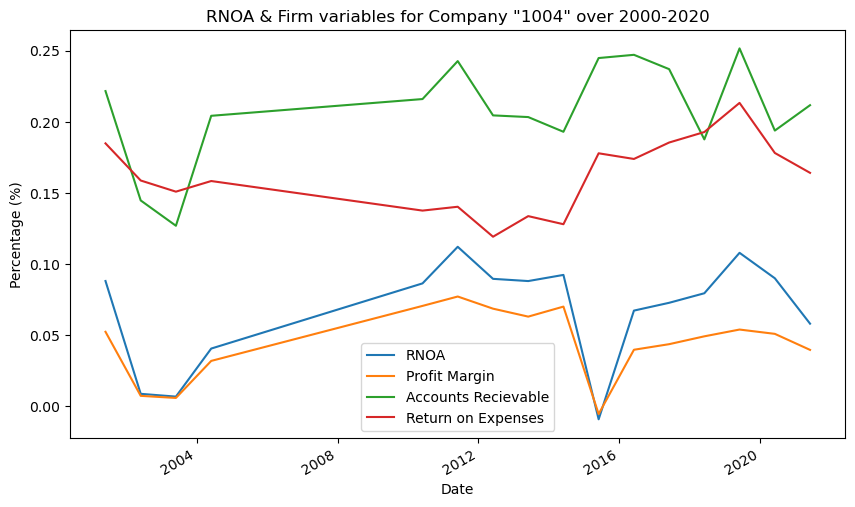

In [353]:
# index for date
a_df4.index = pd.DatetimeIndex(a_df4.Date)

# plot data
fig, ax = plt.subplots(figsize=(10, 6))

a_df4.RNOA.plot(label='RNOA')
a_df4.PM.plot(label='Profit Margin')
a_df4.AR.plot(label='Accounts Recievable')
a_df4.SGX.plot(label='Return on Expenses')

ax.set(title='RNOA & Firm variables for Company "1004" over 2000-2020',
      xlabel='Date', ylabel = 'Percentage (%)')

ax.legend(loc = 'best')

plt.show()

Looking at the plot Profit Margin closely tracks *RNOA*. Taking profit margin and present and future *RNOA* for another random company, gives a good indication whether profit margin is a strong indicator of *RNOA* or whether it was just closely linked in this instance.

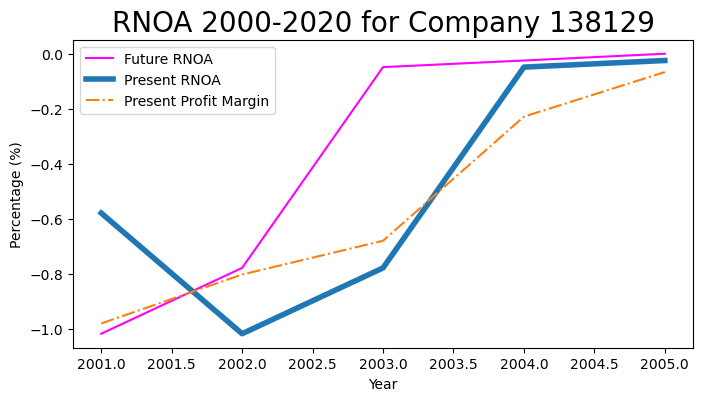

In [354]:
# create plot

x = a_df3[(a_df3["Company ID"] == 138129) & (a_df3["Fiscal Year"] > 2000)]['Fiscal Year']
y1 = a_df3[(a_df3["Company ID"] == 138129) & (a_df3["Fiscal Year"] > 2000)]['RNOA1']
y2 = a_df3[(a_df3["Company ID"] == 138129) & (a_df3["Fiscal Year"] > 2000)]['RNOA']
y3 = a_df3[(a_df3["Company ID"] == 138129) & (a_df3["Fiscal Year"] > 2000)]['PM']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y1, label = 'Future RNOA', color = 'fuchsia')
ax.plot(x, y2, label = 'Present RNOA', linewidth = 4)
ax.plot(x, y3, label = 'Present Profit Margin', linestyle = 'dashdot')

ax.set_title('RNOA 2000-2020 for Company 138129', fontsize = 20)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
plt.legend(loc="best");

plt.show()

Profit margin and present *RNOA* seem to track the movement of future *RNOA* quite well. By conducting a correlation analysis of the regression variables, the correlation coefficients, and therefore relationship strength, between the financial ratios and future *RNOA* can be more clearly established.

          RNOA1      RNOA        PM       ATO      TACC       INV        AR  \
RNOA1  1.000000 -0.000009 -0.000366  0.000009  0.000279  0.000009  0.000009   
RNOA  -0.000009  1.000000 -0.000596 -1.000000  0.000275 -1.000000 -1.000000   
PM    -0.000366 -0.000596  1.000000  0.000596 -0.003118  0.000596  0.000596   
ATO    0.000009 -1.000000  0.000596  1.000000 -0.000275  1.000000  1.000000   
TACC   0.000279  0.000275 -0.003118 -0.000275  1.000000 -0.000275 -0.000275   
INV    0.000009 -1.000000  0.000596  1.000000 -0.000275  1.000000  1.000000   
AR     0.000009 -1.000000  0.000596  1.000000 -0.000275  1.000000  1.000000   
ETR   -0.000008 -0.000008  0.000076  0.000008 -0.000695  0.000008  0.000008   
SGX    0.000009 -1.000000  0.000596  1.000000 -0.000275  1.000000  1.000000   

            ETR       SGX  
RNOA1 -0.000008  0.000009  
RNOA  -0.000008 -1.000000  
PM     0.000076  0.000596  
ATO    0.000008  1.000000  
TACC  -0.000695 -0.000275  
INV    0.000008  1.000000  
AR     0.0000

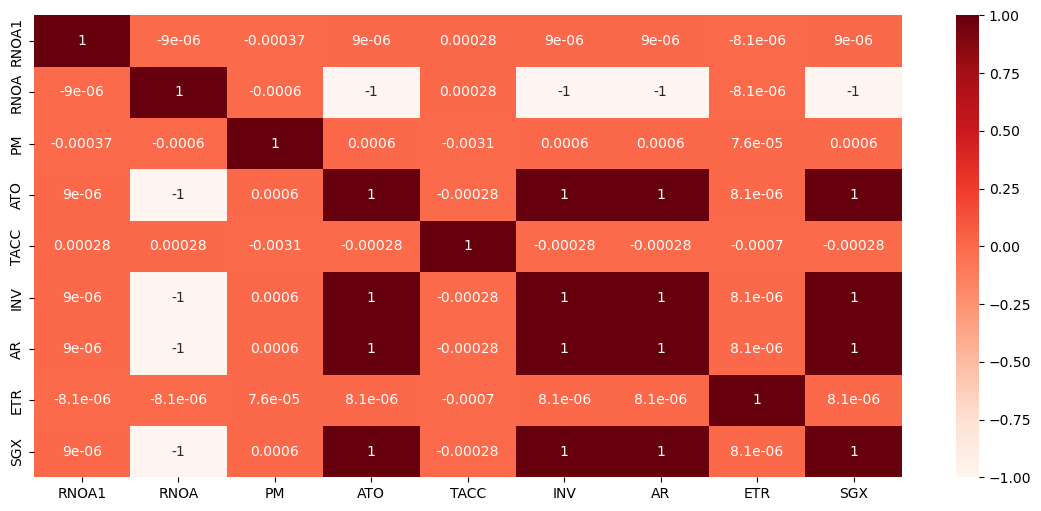

In [355]:
# correlation matrix
correlation_matrix = a_df3[['RNOA1', 'RNOA', 'PM', 'ATO', 'TACC', 'INV', 'AR', 'ETR', 'SGX']].corr()
print(correlation_matrix)

# visualize using heat map
import seaborn as sns

%matplotlib inline

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(correlation_matrix, cmap = 'Reds', annot = True)
plt.show()

The correlation matrix illustrates that future-period *RNOA* has very weak linear relationships with all 8 present-period financial ratios. Of particular interest is that present-period *RNOA* shows a very weak and negative relationship with future-period *RNOA* across this dataset. Profit margins (-0.0004) and change in total accruals (0.0003) show the strongest impact on future-period *RNOA*, however they are also incredibly weak in correlation strength and can thus be considered negligible. It is intriguing to note that the previously visualised reltionships that seemed to exist between future-period *RNOA* and present-period *RNOA* and profit margins do not exist across the entire dataset, but only in specific-firm analysis. 

Moreover it is of interest to note that perfectly positive relationships exist between all pairs of the ratios: asset turnover, variable interest rates, accounts recievable and return on selling expenses, as well as perfectly negative correlations existing between present-period *RNOA* and the ratios: asset turnover, variable interest rates, accounts recievable and return on selling expenses. This perfect correlation suggests that the ratios are not independant and therefore may not be suitable to linear regression analysis. 

# Simple Modelling

Earnings per Share data is now analysed using random-walk and moving average models. 

In [268]:
# import the data and normalise the date

eps_df = pd.read_csv('data/EPS.csv')
eps_df.head()

,GVKEY,DATADATE,FYEAR,EPS
0,1004,20100531,2009,1.17
1,1004,20110531,2010,1.76
2,1004,20120531,2011,1.68
3,1004,20130531,2012,1.38
4,1004,20140531,2013,1.85


In [269]:
eps_df.describe()

,GVKEY,DATADATE,FYEAR,EPS
count,84794.000000,8.479400e+04,84794.000000,8.479400e+04
mean,88105.926905,2.014619e+07,2014.403802,9.095729e+01
std,75151.100587,2.913951e+04,2.924401,4.683484e+04
min,1004.000000,2.010013e+07,2009.000000,-4.980000e+06
25%,19640.000000,2.012123e+07,2012.000000,-1.800000e-01
50%,63531.000000,2.014123e+07,2014.000000,6.000000e-02
75%,163949.000000,2.017123e+07,2017.000000,1.300000e+00
max,345980.000000,2.020123e+07,2020.000000,1.258000e+07


It can be seen form the statistics for *EPS* that the minimum and maximum values are quite large, thus possibly distorting the data due to their outlier nature. In order to remedy this, the data is winsorized at the 1st and 99th percentiles.

In [270]:
# winsorize EPS and check the descriptive statistics 
p1 = eps_df["EPS"].quantile(0.01)
p99 = eps_df["EPS"].quantile(0.99)
eps_df2 = eps_df.copy(deep = True)
eps_df2['EPS'].clip(lower = p1, upper = p99, inplace = True)

warnings.filterwarnings("ignore")

eps_df2.describe()

,GVKEY,DATADATE,FYEAR,EPS
count,84794.000000,8.479400e+04,84794.000000,84794.000000
mean,88105.926905,2.014619e+07,2014.403802,0.648134
std,75151.100587,2.913951e+04,2.924401,2.484391
min,1004.000000,2.010013e+07,2009.000000,-7.721400
25%,19640.000000,2.012123e+07,2012.000000,-0.180000
50%,63531.000000,2.014123e+07,2014.000000,0.060000
75%,163949.000000,2.017123e+07,2017.000000,1.300000
max,345980.000000,2.020123e+07,2020.000000,12.620000


The data for *EPS* is now more accurate with a much smaller range around a more accurate mean statistic. The models are now created:

In [271]:
# sort the data
eps3 = eps_df2.sort_values(['GVKEY', 'FYEAR'])

# create lagged EPS plus 1 to 5 years
eps3['EPS Year 1'] = eps3.groupby(['GVKEY'])['EPS'].shift(1)
eps3['EPS Year 2'] = eps3.groupby(['GVKEY'])['EPS'].shift(2)
eps3['EPS Year 3'] = eps3.groupby(['GVKEY'])['EPS'].shift(3)
eps3['EPS Year 4'] = eps3.groupby(['GVKEY'])['EPS'].shift(4)
eps3['EPS Year 5'] = eps3.groupby(['GVKEY'])['EPS'].shift(5)

In [272]:
# contruct random walk and moving average forecasts
# calculate forecast errors 

eps3['RW Model 1'] = eps3['EPS Year 1']
eps3['RW1 Error'] = abs((eps3.EPS - eps3['EPS Year 1'])/eps3.EPS)

eps3['RW Model 2'] = eps3['EPS Year 2']
eps3['RW2 Error'] = abs((eps3.EPS - eps3['EPS Year 2'])/eps3.EPS)

eps3['RW Model 3'] = eps3['EPS Year 3']
eps3['RW3 Error'] = abs((eps3.EPS - eps3['EPS Year 3'])/eps3.EPS)

eps3['MV Model - 2 Years'] = (eps3['EPS Year 1'] + eps3['EPS Year 2'])/2
eps3['MV2 Error'] = abs(((eps3.EPS - eps3['MV Model - 2 Years'])/eps3.EPS))

eps3['MV Model - 3 Years'] = (eps3['EPS Year 1'] + eps3['EPS Year 2'] + eps3['EPS Year 3'])/3
eps3['MV3 Error'] = abs(((eps3.EPS - eps3['MV Model - 3 Years'])/eps3.EPS))

eps3['MV Model - 5 Years'] = (eps3['EPS Year 1'] + eps3['EPS Year 2'] + eps3['EPS Year 3'] + eps3['EPS Year 4'] + eps3['EPS Year 5'])/5
eps3['MV5 Error'] = abs(((eps3.EPS - eps3['MV Model - 5 Years'])/eps3.EPS))

# rename variables comapny ID and fiscal year, remove datadate
eps3 = eps3.rename(columns = {'GVKEY': 'Company ID', 'FYEAR' : 'Fiscal Year'})
eps3.drop(columns = ['DATADATE'], inplace = True)

eps3.head(10)

,Company ID,Fiscal Year,EPS,EPS Year 1,EPS Year 2,EPS Year 3,EPS Year 4,EPS Year 5,RW Model 1,RW1 Error,RW Model 2,RW2 Error,RW Model 3,RW3 Error,MV Model - 2 Years,MV2 Error,MV Model - 3 Years,MV3 Error,MV Model - 5 Years,MV5 Error
0,1004,2009,1.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1004,2010,1.76,1.17,NaN,NaN,NaN,NaN,1.17,0.335227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1004,2011,1.68,1.76,1.17,NaN,NaN,NaN,1.76,0.047619,1.17,0.303571,NaN,NaN,1.465,0.127976,NaN,NaN,NaN,NaN
3,1004,2012,1.38,1.68,1.76,1.17,NaN,NaN,1.68,0.217391,1.76,0.275362,1.17,0.152174,1.720,0.246377,1.536667,0.113527,NaN,NaN
4,1004,2013,1.85,1.38,1.68,1.76,1.17,NaN,1.38,0.254054,1.68,0.091892,1.76,0.048649,1.530,0.172973,1.606667,0.131532,NaN,NaN
5,1004,2014,0.26,1.85,1.38,1.68,1.76,1.17,1.85,6.115385,1.38,4.307692,1.68,5.461538,1.615,5.211538,1.636667,5.294872,1.568,5.030769
6,1004,2015,1.37,0.26,1.85,1.38,1.68,1.76,0.26,0.810219,1.85,0.350365,1.38,0.007299,1.055,0.229927,1.163333,0.150852,1.386,0.011679
7,1004,2016,1.66,1.37,0.26,1.85,1.38,1.68,1.37,0.174699,0.26,0.843373,1.85,0.114458,0.815,0.509036,1.160000,0.301205,1.308,0.212048
8,1004,2017,0.44,1.66,1.37,0.26,1.85,1.38,1.66,2.772727,1.37,2.113636,0.26,0.409091,1.515,2.443182,1.096667,1.492424,1.304,1.963636
9,1004,2018,0.20,0.44,1.66,1.37,0.26,1.85,0.44,1.200000,1.66,7.300000,1.37,5.850000,1.050,4.250000,1.156667,4.783333,1.116,4.580000


Having constructed the models, the forecast errors are compared and contrasted using their mean error rates and t-tests to look for statistical significance between actual *EPS* data and the modelled data.

In [274]:
# look at forecast errors

eps3[['RW1 Error', 'RW2 Error', 'RW3 Error', 'MV2 Error', 'MV3 Error', 'MV5 Error']].describe()

,RW1 Error,RW2 Error,RW3 Error,MV2 Error,MV3 Error,MV5 Error
count,7.077600e+04,5.922900e+04,4.883600e+04,5.936000e+04,4.896100e+04,3.102800e+04
mean,inf,inf,inf,inf,inf,inf
std,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.860465e-01,2.682927e-01,3.200000e-01,2.205882e-01,2.380952e-01,2.695543e-01
50%,5.185185e-01,6.666667e-01,7.462363e-01,5.508475e-01,5.769231e-01,6.047619e-01
75%,1.210526e+00,1.473684e+00,1.600000e+00,1.281250e+00,1.310345e+00,1.350000e+00
max,inf,inf,inf,inf,inf,inf


In [309]:
# remove missing values and infinite values

eps3.replace([np.inf, -np.inf], np.nan, inplace = True)
eps3.dropna(subset = ['RW1 Error', 'RW2 Error', 'RW3 Error', 'MV2 Error', 'MV3 Error', 'MV5 Error'], inplace = True)

eps3[['RW1 Error', 'RW2 Error', 'RW3 Error', 'MV2 Error', 'MV3 Error', 'MV5 Error']].describe()

,RW1 Error,RW2 Error,RW3 Error,MV2 Error,MV3 Error,MV5 Error
count,30262.000000,30262.000000,30262.000000,30262.000000,30262.000000,30262.000000
mean,1.929296,2.318297,2.455765,1.900475,1.867122,1.882855
std,9.977421,12.084061,11.632668,9.367438,8.377167,7.887150
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.164835,0.247287,0.294118,0.200000,0.222222,0.263636
50%,0.493151,0.606588,0.680672,0.500000,0.534403,0.588889
75%,1.152051,1.375000,1.487286,1.196678,1.212328,1.242098
max,653.000000,773.140000,771.140000,535.570000,339.046667,339.856000


The statistics for the random walk models show that the model is most accurate for the first year with a mean of 1.929, whereas in the 2nd and 3rd year the accuracy declines to 2.318 and then 2.455. Intuitively this makes sense, as the random walk model uses baseline data and then random probabilites to forecast future earnings, as such the further the baseline data is in the past, the less reliable the forecasts are. 

Likewise a similiar but inverse pattern emerges for the moving average models: for 2 years the model has a mean of 1.9 (more accurate then the random walk model), however as more data is added to the model it becomes increasingly more accurate. At 3 years, the model has a mean of 1.867, and for 5 years of data the model has a mean of 1.882. 

The difference in accuracy of these two models, if any exists, can be ascertained using a t-test statistic.

In [310]:
from scipy import stats 

# calculate the differences in forecast error between the models
eps3['MV5-MV3'] = eps3['MV5 Error'] - eps3['MV3 Error']
eps3['RW1-MV5'] = eps3['RW1 Error'] - eps3['MV5 Error']
eps3['RW1-MV3'] = eps3['RW1 Error'] - eps3['MV3 Error']

# test the difference between RW1 and MV2
out1 = stats.ttest_1samp(eps3['MV5-MV3'], popmean = 0)
out2 = stats.ttest_1samp(eps3['RW1-MV5'], popmean = 0)
out3 = stats.ttest_1samp(eps3['RW1-MV3'], popmean = 0)

# create data frame for t-tests
frame1 = pd.DataFrame(out1, index = ['t_statistic', 'p_value'], columns = ['MV5-MV3'])
frame2 = pd.DataFrame(out2, index = ['t_statistic', 'p_value'], columns = ['RW1-MV5'])
frame3 = pd.DataFrame(out3, index = ['t_statistic', 'p_value'], columns = ['RW1-MV3'])

merged_df = pd.merge(frame1, frame2, left_index=True, right_index=True)
Ttests = pd.merge(merged_df, frame3, left_index=True, right_index=True)
Ttests

,MV5-MV3,RW1-MV5,RW1-MV3
t_statistic,0.612335,0.959001,1.584557
p_value,0.540321,0.337566,0.113077


The null hypothesis of the t-test is that there is no significant difference between the mean of one model over another. Conversley if any of the models are superior than the other, statistical significance from a p-value below a significance level (say, 5.0%) should be observed. The t-test between the better models: random walk after 1 year, moving average models after 3 years and 5 years, all show no statistical significance. The test shows that there is a 54% chance that no signifcant variation exists between the two moving average models, that there is a 33.75% chance that no difference exists between that random walk modeal after 1 year and the moving average model over 5 years, and an 11.3% chance that no significant difference exists between the random walk model and the moving average model over 3 years. If the significance level were relaxed to 0.15, statistical significance could be found for the the moving average model over 3 years, but this is not the norm. 

As such the tests conclude that whilst the moving average models appear to outperform the random walk models in predicting *EPS* in this dataset, there is no statistical evidence to suggest that they always do, or are more accurate then the random walk models.

# Complex Modelling

Multilinear regression is now run for future-period *RNOA*, as well as future-period *ROA* (return on assets).  

In [360]:
import statsmodels.formula.api as smf

# run regression analysis for ROA
formula = 'ROA ~ RNOA + PM + ATO + TACC + INV + AR + ETR + SGX'
model = smf.ols(formula, data = a_df3)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    ROA   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.397
Date:                Sun, 08 Jun 2025   Prob (F-statistic):             0.0189
Time:                        14:30:44   Log-Likelihood:            -2.0936e+05
No. Observations:              110712   AIC:                         4.187e+05
Df Residuals:                  110704   BIC:                         4.188e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0328      0.005     -6.773      0.000      -0.042      -0.023
RNOA           0.0004      0.000      0.953      0.340      -0.000       0.001
PM             0.0002   7.46e-05      3.325      0.001       0.000       0.000
ATO           -0.0002      0.000     -1.126      0.260      -0.001       0.000
TACC       -1.923e-06   1.87e-06     -1.028      0.304   -5.59e-06    1.74e-06
INV            0.0008      0.001      0.885      0.376      -0.001       0.002
AR         -5.062e-06   2.66e-05     -0.191      0.849   -5.71e-05     4.7e-05
ETR         6.502e-05      0.000      0.310      0.756      -0.000       0.000
SGX            0.0003      0.000      0.919      0.358      -0.000       0.001
==============================================================================
Omnibus:                   489626.546   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):    2778607214773.700
Skew:                        -141.898   Prob(JB):                         0.00
Kurtosis:                   24544.032   Cond. No.                     9.63e+14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.63e+14. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The *R*-squared statistic shows that none of the independant variables account for any variation in *ROA*. Moreover the variable coefficents are negligible in their impact on the model and p-values are all much higher then 5% significance levels - except for profit margin - indicating that the variables do not account for any changes in *ROA*. 

In [361]:
# run regression analysis for RNOA is time period t+1
formula = 'RNOA1 ~ RNOA + PM + ATO + TACC + INV + AR + ETR + SGX'
model = smf.ols(formula, data = a_df3)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  RNOA1   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.004312
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               1.00
Time:                        15:33:07   Log-Likelihood:            -3.9351e+06
No. Observations:              110712   AIC:                         7.870e+06
Df Residuals:                  110704   BIC:                         7.870e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.996e+12      2e+12      1.000      0.317   -1.92e+12    5.91e+12
RNOA       -5.317e+09   1.56e+11     -0.034      0.973    -3.1e+11       3e+11
PM         -3.731e+09   3.08e+10     -0.121      0.903    -6.4e+10    5.65e+10
ATO        -4.913e+08   8.46e+10     -0.006      0.995   -1.66e+11    1.65e+11
TACC        7.128e+07   7.71e+08      0.092      0.926   -1.44e+09    1.58e+09
INV          2.08e+10   3.49e+11      0.060      0.953   -6.64e+11    7.06e+11
AR          1.557e+07   1.09e+10      0.001      0.999   -2.14e+10    2.15e+10
ETR        -2.268e+08   8.63e+10     -0.003      0.998   -1.69e+11    1.69e+11
SGX        -5.732e+09    1.5e+11     -0.038      0.970      -3e+11    2.88e+11
==============================================================================
Omnibus:                   623420.674   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   56539093011405.180
Skew:                         332.729   Prob(JB):                         0.00
Kurtosis:                  110709.940   Cond. No.                     9.63e+14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.63e+14. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Again the *R*-squared statistic shows that none of the independant variables account for any variation in *RNOA*. The variable p-values are all much higher then 5% significance levels, indicating that the variables do not account for any changes in *RNOA*. 

In [363]:
# develop forecast errors for linear regression versus a simple random walk model
result.fittedvalues.head()
pred = pd.DataFrame(result.fittedvalues, columns=['Predicted RNOA'])
a_df4 = pd.merge(a_df3, pred, left_index=True, right_index=True)

a_df4['Error'] = abs(a_df4['RNOA1'] - a_df4['Predicted RNOA'])

# random walk model error
a_df4['Error RW'] = abs(a_df4['RNOA1'] - a_df4['RNOA'])

a_df4[['Error', 'Error RW']].describe()

,Error,Error RW
count,1.107120e+05,1.107120e+05
mean,3.977425e+12,3.971785e+12
std,6.607621e+14,9.344716e+14
min,2.949430e+09,0.000000e+00
25%,1.986461e+12,1.994116e-02
50%,1.993331e+12,5.973973e-02
75%,1.998048e+12,1.769809e-01
max,2.198601e+17,2.198621e+17


In [364]:
# remove extreme values in errors
a = a_df4['Error'].quantile(0.99)
b = a_df4['Error RW'].quantile(0.99)
a_df4.loc[(a_df4.Error < a) & (a_df4['Error RW'] < b)][['Error', 'Error RW']].describe()

,Error,Error RW
count,1.086830e+05,108683.000000
mean,1.979280e+12,0.311754
std,9.765513e+10,1.070853
min,2.949430e+09,0.000000
25%,1.986375e+12,0.019639
50%,1.993249e+12,0.058311
75%,1.997774e+12,0.168694
max,2.184777e+12,14.216837


The forecasting errors show a significant disparity between the linear regression model error and the random walk model error (which is much smaller at 0.311). This indicates that the linear model relied upon indpendant variables which were not related to forecasting Returns on Net Operating Assets, and that a more simple model such as the random walk model is better able to predict future *RNOA* on more limtied information. This result is not surprising however, as the correlation coefficients studied in section 2 of this analysis confirmed that (1) many of the variables have little correlation, and (2) other variables are not independant of each other and therefore not suitable to linear regression modelling.  

# Conclusion

This report has analysed the efficacy of linear regression in predicting *RNOA* from a series of commonly listed financial ratios. Correlation analysis found that there was little assocation between most variables, whilst other were perfectly correlated suggesting non-independance. Regression analysis further found that the financial ratios were not predictive of either returns on net assets or returns on assets, with *p*-values being significantly higher then the 5% significance levels and *R*-squared statistics being at 0.00. Moreover forecast errors between the predicted regression model *RNOA* values for future periods and a simple 1-year random walk model showed that the random walk model was significantly better at predicting future-period *RNOA*. 

Earnings per share was studied using random wak models at 1, 2 and 3 year future periods, and with moving average models using 2, 3 and 5 years of previous data. Whilst the moving average models using 3 and 5 years of data were more accurate in predicting future-period *EPS* then the random walk models, the best random walk model (at 1 year) and these moving average models were not found to have a statistically significant difference, such that it can not be inferred that the moving average model is better then the random walk model. 

Moreover this study could be improved in future analyses by researching variables which are truly independant of *RNOA* and each other, and which experts purport to be predictive of *RNOA* to inform future linear regression models. 

# References

Schmidt M (2021) *Reverse Engineering Return on Equity*, Investopedia, accessed 6 June 2025. https://www.investopedia.com/articles/fundamental-analysis/09/financial-ratios.asp#:~:text=While%20return%20on%20equity%20

Soliman, MT (2008) The use of DuPont analysis by market participants, *The Accounting Review*, 83(3):823-853.

Xero (2024) *What is earnings per share (EPS)?* Xero, accessed 6 June 2025. https://www.xero.com/au/glossary/earnings-per-share/